In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
import os

In [12]:
# Cargamos los csv de los tifs
path = "saved_files/dataset"
dfs = {}
for archivo in os.listdir(path):
    if archivo.endswith("_features.csv") and "TOA" not in archivo:
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        dfs[nombre_sin_extension[:-9]] = pd.read_csv(ruta_completa)

Como hay algunos días y puntos concretos en los que las reflectancias son 0 y los índices por tanto se han calculado como NaN, limpiamos los datasets de esas filas:

In [14]:
for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        dfs[nombre_df] = df.dropna()

Las fórmulas que queremos comprobar son:

- $y_1 = 0.6386 e^{4.7513x}$, donde $y$ es la clorofila y $x$ es la relación de $(Green - Blue)/(Green + Blue)$

- $y_2 = 124.94x - 115.35$ donde $x = \frac{Green+NIR1}{Green + Red}$

- $y_3 = 22.835x - 12.974$ donde $x = \frac{NIR1 - NIR2}{Red - NIR2}$

- $y_4 = 32.448x - 21.408$ donde $x = \frac{NIR1}{Red}$

- $y_5 = 0.353RG^3 + 2.132𝑅𝐺² + 3.905𝑅𝐺 + 2.110$ donde $RG = log_{10} \frac{R670}{R550}$


con las fechas


dates = [
    "28/10/2016", "20/06/2018", "07/11/2018", "14/08/2019",
    "30/06/2017", "10/07/2018", "12/03/2019", "18/09/2019",
    "20/02/2018", "29/08/2018", "25/06/2019", "03/10/2019",
    "07/03/2018", "03/10/2018"
]


Filtramos los dataframes para dejar solamente esas fechas:

In [15]:
# Fechas related
# 28/10/2016 no está incluido en el dataset
dates = [
    "28/10/2016", "30/06/2017", "20/02/2018", "07/03/2018", "20/06/2018",
    "10/07/2018", "29/08/2018", "03/10/2018", "07/11/2018", "12/03/2019",
    "25/06/2019", "14/08/2019", "03/10/2019", "18/09/2019"
]

filter_dates = pd.to_datetime(dates, format="%d/%m/%Y")


# Todas las fechas
# dates = ['2016-08-09', '2016-09-08', '2017-06-30', '2018-02-20', '2018-03-07', 
#     '2018-05-16', '2018-06-20', '2018-07-10', '2018-08-29', '2018-10-03', #'2019-09-18',
#     '2018-11-07', '2019-03-12', '2019-06-25', '2019-07-10', '2019-07-30', 
#     '2019-08-14', '2019-09-28', '2019-10-03', '2019-11-27', '2020-02-20', 
#     '2020-03-11', '2020-12-21', '2021-01-05', '2021-04-20', '2021-05-20',
#     '2021-06-14', '2021-08-13', '2021-11-11', '2021-11-26', '2021-12-01', 
#     '2022-02-24', '2022-07-14', '2022-07-29', '2022-08-03', '2022-09-07', 
#     '2022-09-27', '2023-01-10', '2023-03-01', '2023-03-16', '2023-04-20', 
#     '2023-05-25']

# filter_dates = pd.to_datetime(dates, format="%Y-%m-%d")


for nombre_df, df in dfs.items():
    df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d", errors='coerce')  # asegurarse
    dfs[nombre_df] = df[df["Date"].isin(filter_dates)].copy()

Recordemos que en el paper quitan las observaciones cuya medida de Chl-a esté fuera de la mediana $\pm$ una desviación estándar. Para ello hacemos lo siguiente (no lo hacemos porque los resultados empeoran muchísimo.). De hacerlo, pasaríamos de tener 130 filas, a quedarnos solamente con 107.

In [69]:
# for nombre_df, df in dfs.items():
#     if "Chl" in df.columns:
#         mediana = df["Chl"].median()
#         desviacion = df["Chl"].std()
#         umbral_sup = mediana + desviacion
#         umbral_inf = mediana - desviacion

#         # Filtrar
#         df_filtrado = df[(df["Chl"] >= umbral_inf) & (df["Chl"] <= umbral_sup)].copy()
#         dfs[nombre_df] = df_filtrado

Definimos funciones para las fórmulas que queremos aplicar.
Recordar que:
- Blue = rhow_B2
- Green = rhow_B3
- Red = rhow_B4
- NIR1 = rhow_B5
- NIR2 = rhow_B6

In [16]:
def add_y(blue, green, red, nir1, nir2):
    x_1 = (green-blue)/(green+blue)
    y_1 = 0.6386*np.exp(4.7513*x_1)

    x_2 = (green+nir1)/(green+red)
    y_2 = 124.94*x_2 - 115.35

    x_3 = (nir1-nir2)/(red-nir2)
    y_3 = 22.835*x_3 - 12.974

    x_4 = nir1/red
    y_4 = 32.448*x_4 - 21.408

    x_5 = np.log10(red/green)
    y_5 = 0.353*(x_5**3) + 2.132*(x_5**2) + 3.905*x_5 + 2.110
    return y_1, y_2, y_3, y_4, y_5

In [17]:
def add_y_columns_to_df(df, band_set="rhow", correct=False):
    # Mapas de bandas
    mapping = band_maps[band_set]

    # Extraer bandas desde el DataFrame
    blue = df[mapping["Blue"]]
    green = df[mapping["Green"]]
    red = df[mapping["Red"]]
    nir1 = df[mapping["NIR1"]]
    nir2 = df[mapping["NIR2"]]

    # Aplicar fórmula
    y_1, y_2, y_3, y_4, y_5 = add_y(blue, green, red, nir1, nir2)

    if correct:
        y_1 = np.clip(y_1, 1, None)
        y_2 = np.clip(y_2, 1, None)
        y_3 = np.clip(y_3, 1, None)
        y_4 = np.clip(y_4, 1, None)
        y_5 = np.clip(y_5, 1, None)

    # Añadir columnas al DataFrame
    if band_set == "rhow":
        df["y_1_rhow"] = y_1
        df["y_2_rhow"] = y_2
        df["y_3_rhow"] = y_3
        df["y_4_rhow"] = y_4
        df["y_5_rhow"] = y_5

    elif band_set == "rhown":
        df["y_1_rhown"] = y_1
        df["y_2_rhown"] = y_2
        df["y_3_rhown"] = y_3
        df["y_4_rhown"] = y_4
        df["y_5_rhown"] = y_5

    return df

band_maps = {
    "rhow": {
        "Blue": "rhow_B2",
        "Green": "rhow_B3",
        "Red": "rhow_B4",
        "NIR1": "rhow_B5",
        "NIR2": "rhow_B6"
    },
    "rhown": {
        "Blue": "rhown_B2",
        "Green": "rhown_B3",
        "Red": "rhown_B4",
        "NIR1": "rhown_B5",
        "NIR2": "rhown_B6"
    }
}

In [20]:
correct = False # Correction to clip negative values to 0
for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        print(nombre_df, band_set)
        try:
            dfs[nombre_df] = add_y_columns_to_df(df, band_set, correct)
        except:
            continue

C2X-Complex_rhow_9x9_depth_eq_0 rhow
C2X-Complex_rhow_9x9_depth_eq_0 rhown
C2X-Complex_rhow_15x15_depth_eq_0 rhow
C2X-Complex_rhow_15x15_depth_eq_0 rhown
C2X_rhown_9x9_depth_in_0_1 rhow
C2X_rhown_9x9_depth_in_0_1 rhown
C2RCC_rhown_5x5_depth_in_1_2 rhow
C2RCC_rhown_5x5_depth_in_1_2 rhown
C2X-Complex_rhown_5x5_depth_lt_2 rhow
C2X-Complex_rhown_5x5_depth_lt_2 rhown
C2X_rhown_15x15_depth_eq_0 rhow
C2X_rhown_15x15_depth_eq_0 rhown
C2X-Complex_rhown_1x1_depth_gt_4 rhow
C2X-Complex_rhown_1x1_depth_gt_4 rhown
C2RCC_rhown_5x5_depth_gt_3 rhow
C2RCC_rhown_5x5_depth_gt_3 rhown
C2X-Complex_rhow_9x9_depth_in_0_1 rhow
C2X-Complex_rhow_9x9_depth_in_0_1 rhown
C2X_rhow_3x3_depth_eq_1 rhow
C2X_rhow_3x3_depth_eq_1 rhown
C2RCC_rhown_3x3_depth_in_3_4 rhow
C2RCC_rhown_3x3_depth_in_3_4 rhown
C2X_rhown_5x5_depth_gt_3 rhow
C2X_rhown_5x5_depth_gt_3 rhown
C2X_rhown_5x5_depth_in_2_3 rhow
C2X_rhown_5x5_depth_in_2_3 rhown
C2X_rhow_5x5_depth_gt_1 rhow
C2X_rhow_5x5_depth_gt_1 rhown
C2X-Complex_rhown_15x15_depth_eq_1 r

In [35]:
dfs["C2RCC_rhow_15x15_depth_eq_0"][["rhow_B4","rhow_B3"]].iloc[:50]

,rhow_B4,rhow_B3
23,0.011678,0.041878
24,0.006652,0.031059
25,0.005466,0.022939
26,0.007815,0.029618
27,0.004923,0.031391
28,0.007550,0.028345
29,0.011477,0.047304
30,0.007727,0.033660
31,0.027319,0.060960
32,0.006490,0.025112


In [21]:
metrics_df = pd.DataFrame()
for nombre_df, df in dfs.items():
    
    # R2 (coeficiente de determinación)
    try:
        metrics_df.loc[nombre_df, "r2_y_1_rhow"] = r2_score(df["Chl"], df["y_1_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_2_rhow"] = r2_score(df["Chl"], df["y_2_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_3_rhow"] = r2_score(df["Chl"], df["y_3_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_4_rhow"] = r2_score(df["Chl"], df["y_4_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_5_rhow"] = r2_score(df["Chl"], df["y_5_rhow"]).round(3)
    except:
        continue

    try:
        metrics_df.loc[nombre_df, "r2_y_1_rhown"] = r2_score(df["Chl"], df["y_1_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_2_rhown"] = r2_score(df["Chl"], df["y_2_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_3_rhown"] = r2_score(df["Chl"], df["y_3_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_4_rhown"] = r2_score(df["Chl"], df["y_4_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_5_rhown"] = r2_score(df["Chl"], df["y_5_rhown"]).round(3)
    except:
        continue

    # Coeficiente de correlación (correlación lineal)
    # try:
    #     metrics_df.loc[nombre_df, "corr_y_1_rhow"] = df["Chl"].corr(df["y_1_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_2_rhow"] = df["Chl"].corr(df["y_2_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_3_rhow"] = df["Chl"].corr(df["y_3_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_4_rhow"] = df["Chl"].corr(df["y_4_rhow"]).round(3)
    # except:
    #     continue

    # try:
    #     metrics_df.loc[nombre_df, "corr_y_1_rhown"] = df["Chl"].corr(df["y_1_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_2_rhown"] = df["Chl"].corr(df["y_2_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_3_rhown"] = df["Chl"].corr(df["y_3_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_4_rhown"] = df["Chl"].corr(df["y_4_rhown"]).round(3)
    # except:
    #     continue

    # RMSE
    # try:
    # metrics_df.loc[nombre_df, "rmse_y_1_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_1_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_2_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_2_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_3_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_3_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_4_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_4_rhow"])).round(3)
    # except:
    # continue

    # try:
    # metrics_df.loc[nombre_df, "rmse_y_1_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_1_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_2_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_2_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_3_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_3_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_4_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_4_rhown"])).round(3)
    # except:
    # continue

    # #NRMSE
    # try:
    # metrics_df.loc[nombre_df, "nrmse_y_1_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_1_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_2_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_2_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_3_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_3_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_4_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_4_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # except:
    # continue

In [22]:
metrics_df.sort_values(by=["r2_y_2_rhow"], ascending=False)

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_5_rhow
C2X_rhow_15x15_depth_lt_1,0.248,0.712,0.706,0.638,-0.056
C2X_rhow_15x15_depth_in_0_1,0.248,0.712,0.706,0.638,-0.056
C2X_rhow_15x15_depth_in_1_2,0.232,0.703,0.725,0.676,-0.150
C2X_rhow_5x5_depth_lt_1,0.251,0.684,0.719,0.636,-0.052
C2X_rhow_5x5_depth_in_0_1,0.251,0.684,0.719,0.636,-0.052
...,...,...,...,...,...
C2X-Complex_rhow_9x9_depth_gt_3,-0.001,-5.501,-4.899,-3.757,-0.415
C2X-Complex_rhow_1x1_depth_in_3_4,-0.032,-5.521,-4.273,-3.354,-0.411
C2X-Complex_rhow_5x5_depth_gt_3,-0.005,-5.667,-4.265,-3.600,-0.400
C2X-Complex_rhow_1x1_depth_gt_4,-0.047,-5.934,-4.636,-3.685,-0.442


In [24]:
metrics_df[metrics_df.gt(0.6).any(axis=1)].sort_values(by=["r2_y_3_rhow"], ascending=False)

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_5_rhow
C2X_rhow_3x3_depth_in_0_1,0.230,0.677,0.728,0.636,-0.052
C2X_rhow_3x3_depth_lt_1,0.230,0.677,0.728,0.636,-0.052
C2X_rhow_15x15_depth_in_1_2,0.232,0.703,0.725,0.676,-0.150
C2X_rhow_3x3_depth_in_1_2,0.223,0.654,0.721,0.646,-0.147
C2X_rhow_5x5_depth_in_0_1,0.251,0.684,0.719,0.636,-0.052
C2X_rhow_5x5_depth_lt_1,0.251,0.684,0.719,0.636,-0.052
C2X_rhow_5x5_depth_in_1_2,0.232,0.656,0.709,0.639,-0.147
C2X_rhow_15x15_depth_in_0_1,0.248,0.712,0.706,0.638,-0.056
C2X_rhow_15x15_depth_lt_1,0.248,0.712,0.706,0.638,-0.056
C2X_rhow_9x9_depth_in_1_2,0.229,0.655,0.698,0.642,-0.149


In [30]:
filtered_df = metrics_df.loc[metrics_df.index.str.contains("upct")]
filtered_df[filtered_df.gt(0.65).any(axis=1)].sort_values(by=["r2_y_2_rhow"], ascending=False)

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_5x5_upct_depth_lt_2,0.236,0.670,0.707,0.621,0.284,0.619,0.648,0.631
c2x-nets_9x9_upct_depth_lt_2,0.225,0.652,0.679,0.600,0.265,0.595,0.620,0.605
c2x-nets_3x3_upct_depth_lt_2,0.217,0.642,0.693,0.602,0.266,0.623,0.661,0.631
c2x-nets_5x5_upct_depth_lt_1,0.232,0.564,0.616,0.512,0.286,0.637,0.655,0.617
c2x-nets_3x3_upct_depth_lt_1,0.200,0.513,0.584,0.472,0.257,0.630,0.661,0.607
c2x-complex-nets_9x9_upct_depth_lt_2,0.058,-0.947,-0.820,-0.450,0.090,0.482,0.658,0.664
c2x-complex-nets_3x3_upct_depth_lt_2,0.053,-0.954,-0.428,-0.344,0.079,0.478,0.673,0.668
c2x-complex-nets_5x5_upct_depth_lt_2,0.053,-1.000,-0.539,-0.369,0.080,0.455,0.680,0.687
c2x-complex-nets_1x1_upct_depth_lt_2,0.054,-1.545,-1.011,-0.652,0.082,0.329,0.655,0.659
c2x-complex-nets_3x3_upct_depth_lt_1,0.094,-1.726,-1.061,-0.940,0.122,0.480,0.676,0.652


In [14]:
from sklearn.linear_model import LinearRegression

df = dfs["C2X_3x3_merge_depth_lt_1"][["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow","Chl"]]
X = df[["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow"]]
y = df["Chl"]

model = LinearRegression().fit(X, y)
pred = model.predict(X)

r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
nrmse = rmse / (np.max(y)- np.min(y)) * 100
print('RMSE: %.3f' % rmse)
print('R squared: %.3f' % r2)
print(f"NRMSE: {nrmse:.1f}%")

RMSE: 1.888
R squared: 0.861
NRMSE: 8.3%


### Scatter plots

In [30]:
def plot_chl_vs_x_rhow(df, nombre_df):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    # Bandas necesarias
    blue = df["rhow_B2"]
    green = df["rhow_B3"]
    red = df["rhow_B4"]
    nir1 = df["rhow_B5"]
    nir2 = df["rhow_B6"]
    chl = df["Chl"]

    # Calcular x_i y modelos teóricos
    x1 = (green - blue) / (green + blue)
    y1 = 0.6386 * np.exp(4.7513 * x1)

    x2 = (green + nir1) / (green + red)
    y2 = 124.94 * x2 - 115.35

    x3 = (nir1 - nir2) / (red - nir2)
    y3 = 22.835 * x3 - 12.974

    x4 = nir1 / red
    y4 = 32.448 * x4 - 21.408

    x5 = np.log10(red/green)
    y5 = 0.353*(x5**3) + 2.132*(x5**2) + 3.905*x5 + 2.110

    x_all = [x1, x2, x3, x4, x5]
    y_all = [y1, y2, y3, y4, y5]
    titles = ["x1 = (G-B)/(G+B)", "x2 = (G+NIR1)/(G+R)", "x3 = (NIR1-NIR2)/(R-NIR2)", "x4 = NIR1/R", "x5 = log10(R/G)"]

    for i in range(5):
        ax = axes[i]
        # Scatter plot de Chl vs combinación de bandas
        ax.scatter(x_all[i], chl, alpha=0.5, label="Chl vs x")
        # Ordenar para trazar la línea del modelo de forma continua
        # x_sorted = np.sort(x_all[i])
        # y_sorted = np.sort(y_all[i])  # opcional: puedes usar y_all[i][x_all[i].argsort()]
        idx_sorted = np.argsort(x_all[i])
        x_sorted = x_all[i].to_numpy()[idx_sorted]
        y_sorted = y_all[i].to_numpy()[idx_sorted]
        # Line plot para la línea del ajuste - 
        ax.plot(x_sorted, y_sorted, 'r-', label="Modelo teórico")
        ax.set_xlabel(f"x{i+1}")
        ax.set_ylabel("Chl")
        ax.set_title(titles[i])
        ax.grid(True)
        ax.legend()

    fig.suptitle(f"Relación Chl vs x_i (rhow) - {nombre_df}")
    plt.tight_layout()
    plt.show()



In [34]:
my_df = dfs["C2X-Complex_rhown_3x3_depth_eq_1"]
#my_df = dfs["c2x-nets_1x1_upct_depth_eq_1"]
my_df.loc[my_df["Chl"]>10,:][["Date","Buoy","Chl", "y_2_rhown", "y_3_rhown", "y_5_rhown"]]

,Date,Buoy,Chl,y_2_rhown,y_3_rhown,y_5_rhown
190,2019-09-18,CTD1,14.2065,13.389414,13.112698,1.278950
191,2019-09-18,CTD2,13.1535,11.911363,11.851215,1.205967
192,2019-09-18,CTD3,11.4810,-3.014376,5.088910,2.654610
193,2019-09-18,CTD4,12.6465,13.908131,13.445674,1.384392
195,2019-09-18,CTD6,13.7330,14.514830,14.291493,1.264318
197,2019-09-18,CTD8,11.7565,12.511235,12.259942,1.330149
198,2019-09-18,CTD9,14.7405,12.457471,12.301171,1.254745
199,2019-09-18,CTD10,15.5420,12.775900,12.638931,1.217793
200,2019-09-18,CTD11,18.2635,10.615845,10.761421,1.121839
201,2019-09-18,CTD12,12.4700,8.474410,8.944214,1.187830


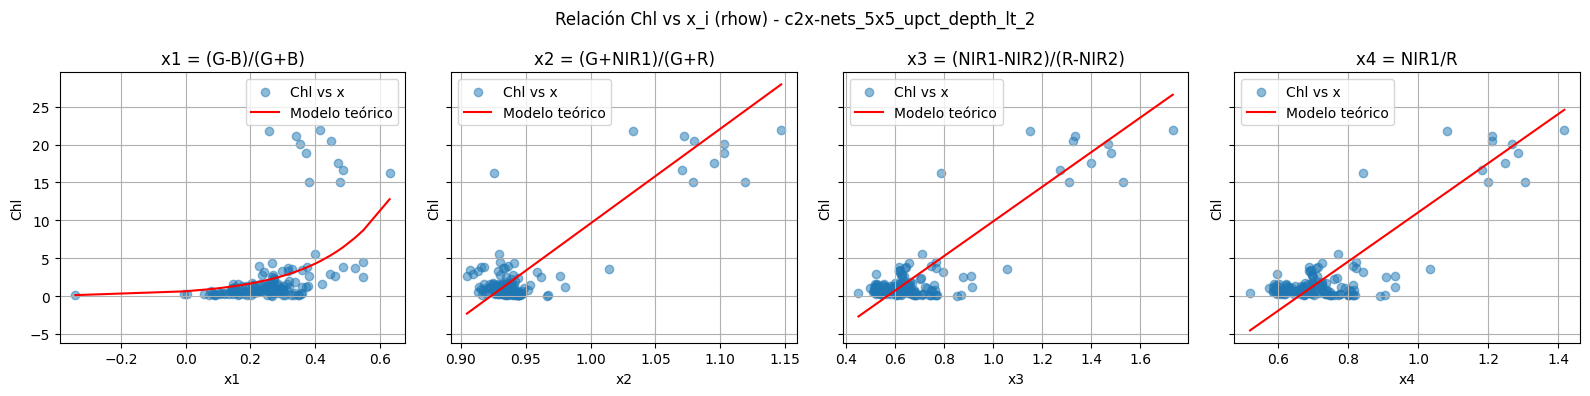

In [36]:
nombres_a_graficar = filtered_df[filtered_df.gt(0.7).any(axis=1)].index #["c2x-nets_3x3_upct_depth_eq_1"]#f
for nombre_df in nombres_a_graficar:
    if nombre_df in dfs:
        df = dfs[nombre_df]
        columnas_necesarias = ["Chl", "rhow_B2", "rhow_B3", "rhow_B4", "rhow_B5", "rhow_B6"]
        if all(col in df.columns for col in columnas_necesarias):
            #plt.savefig("saved_files/ScatterWithDate.png")
            plot_chl_vs_x_rhow(df, nombre_df)


In [272]:
filtered_df[filtered_df.gt(0.7).any(axis=1)].index

Index(['c2x-nets_1x1_upct_depth_lt_2', 'c2x-nets_9x9_upct_depth_lt_2',
       'c2x-nets_3x3_upct_depth_eq_1', 'c2x-nets_9x9_upct_depth_eq_1',
       'c2x-nets_5x5_upct_depth_lt_2', 'c2x-nets_5x5_upct_depth_eq_1',
       'c2x-nets_3x3_upct_depth_lt_2', 'c2x-nets_3x3_upct_depth_lt_1',
       'c2x-nets_5x5_upct_depth_lt_1', 'c2x-nets_1x1_upct_depth_eq_1'],
      dtype='object')

In [312]:
def plot_time_series(df, nombre_df):
    buoys = ["CTD1", "CTD2", "CTD3"]#df["Buoy"].unique() Todas no porque ocupan mucho
    fig, axes = plt.subplots(1, len(buoys), figsize=(16, 3), sharey=True)

    # Bandas necesarias
    # blue = df["rhow_B2"]
    # green = df["rhow_B3"]
    # red = df["rhow_B4"]
    # nir1 = df["rhow_B5"]
    # nir2 = df["rhow_B6"]
    # chl = df["Chl"]

    # # Calcular x_i y modelos teóricos
    # x1 = (green - blue) / (green + blue)
    # y1 = 0.6386 * np.exp(4.7513 * x1)

    # x2 = (green + nir1) / (green + red)
    # y2 = 124.94 * x2 - 115.35

    # x3 = (nir1 - nir2) / (red - nir2)
    # y3 = 22.835 * x3 - 12.974

    # x4 = nir1 / red
    # y4 = 32.448 * x4 - 21.408

    # x_all = [x1, x2, x3, x4]
    # y_all = [y1, y2, y3, y4]
    # titles = ["x1 = (G-B)/(G+B)", "x2 = (G+NIR1)/(G+R)", "x3 = (NIR1-NIR2)/(R-NIR2)", "x4 = NIR1/R"]

    cols_to_plot = ["Chl", "y_1_rhow", "y_2_rhow", "y_3_rhow", "y_4_rhow"]

    for i, buoy in enumerate(buoys):
        for col in cols_to_plot:
            if col in df.columns:
                if col != 'Date':
                    linestyle = '-'
                if col=="Chl":
                    linewidth = 2
                    alpha = 1
                else:
                    linewidth = 1
                    alpha = 0.7
                axes[i].plot(df.loc[df["Buoy"]==buoy]['Date'], df.loc[df["Buoy"]==buoy][col], label=col, linewidth=linewidth, linestyle = linestyle, alpha = alpha, marker="o", markersize=4)
                axes[i].set_title(f"{nombre_df} - {buoy}")
                axes[i].set_xlabel(f"Date")
                axes[i].tick_params(axis='x', rotation=45)
                axes[i].set_ylabel("Chl")
                axes[i].grid(True, linestyle='--')
                axes[i].legend()


    #fig.suptitle(f"Relación Chl vs x_i (rhow) - {nombre_df}")
    plt.tight_layout()
    plt.show()


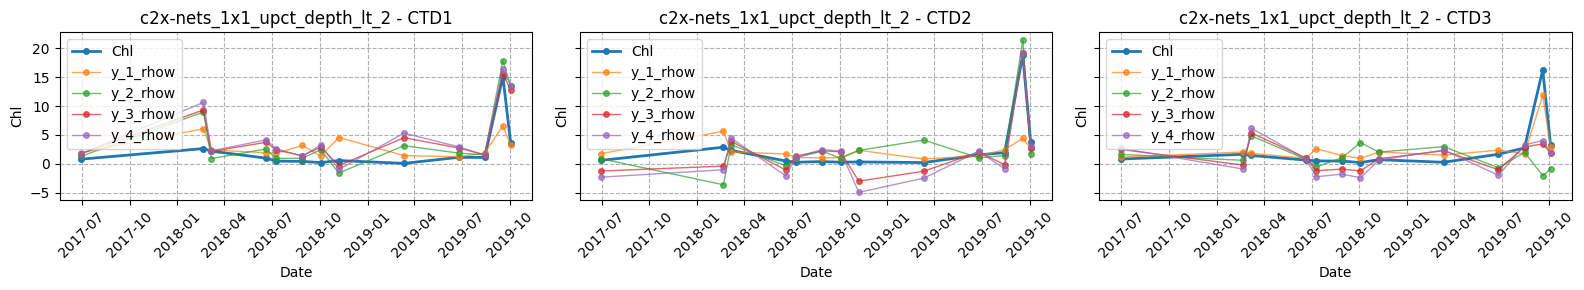

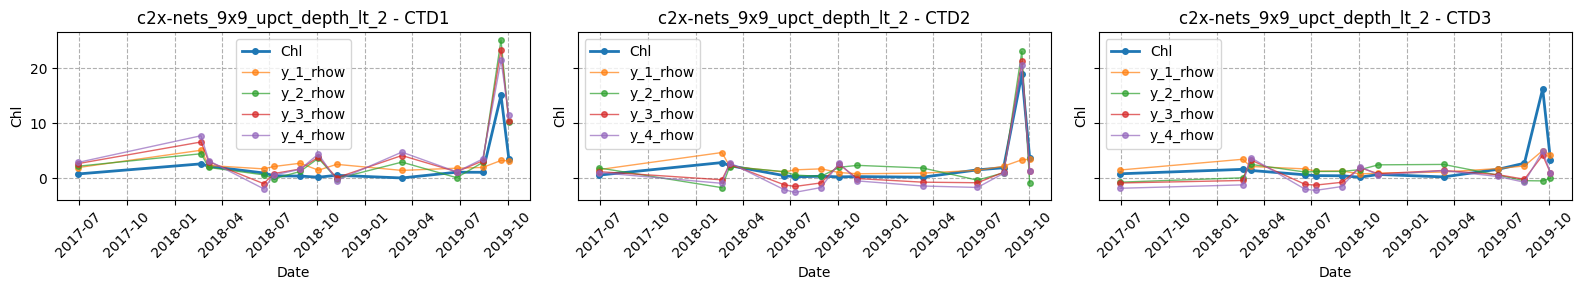

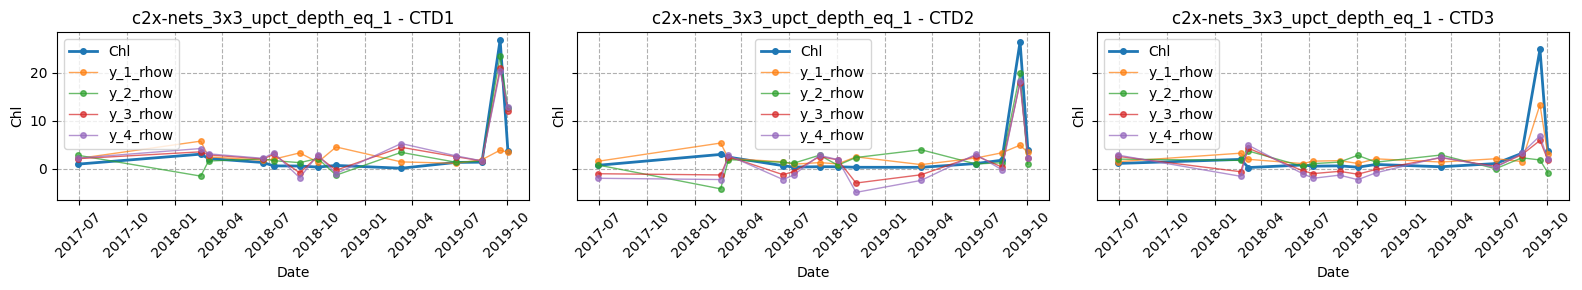

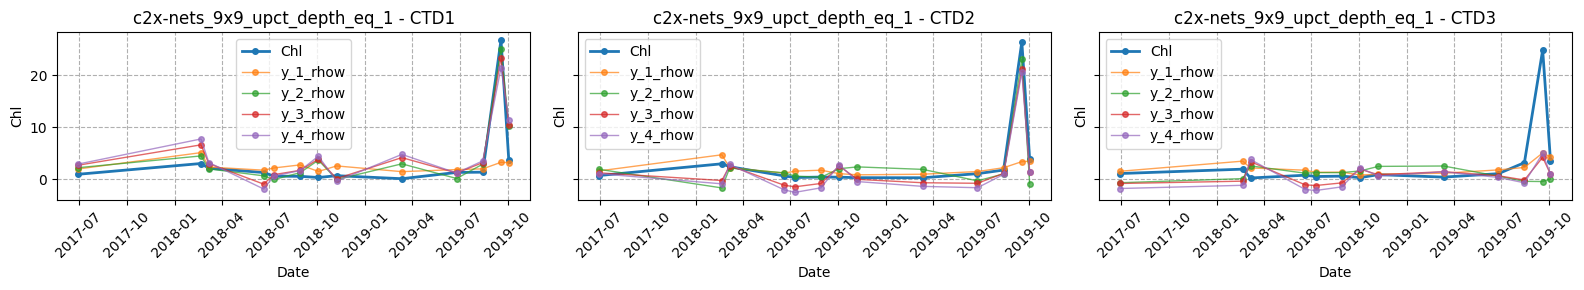

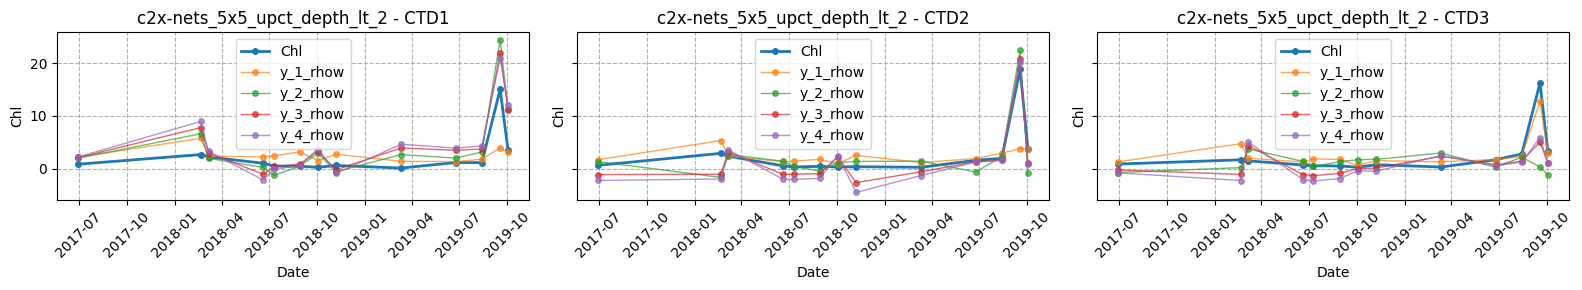

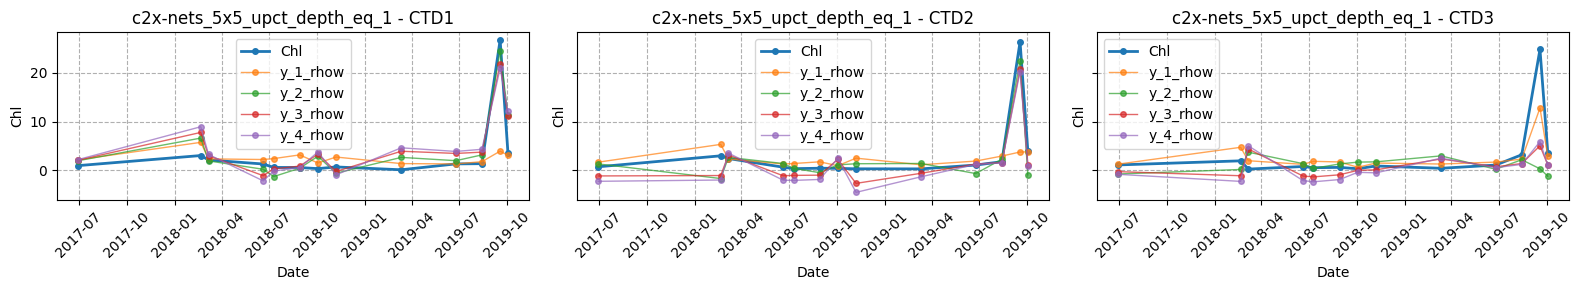

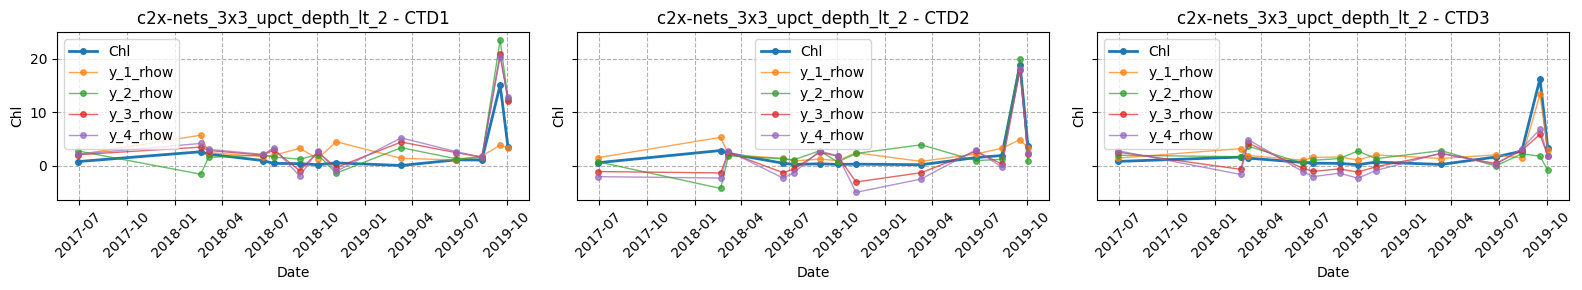

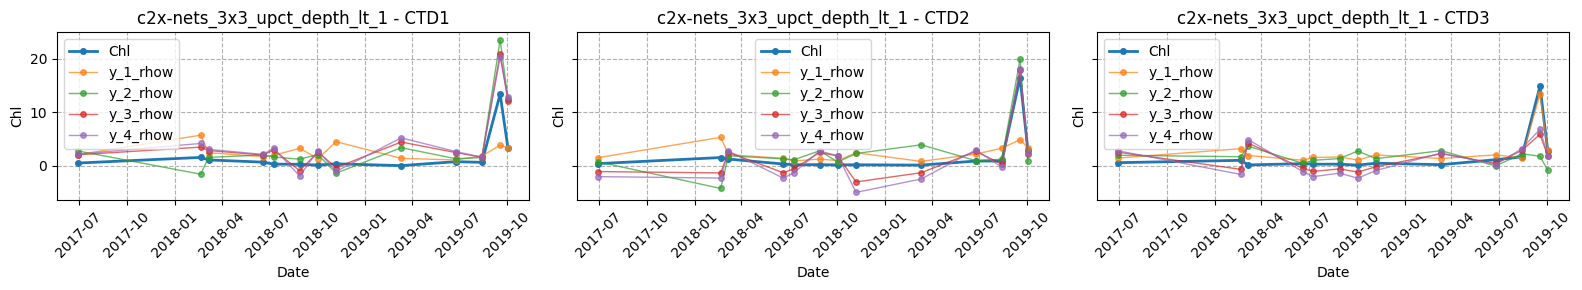

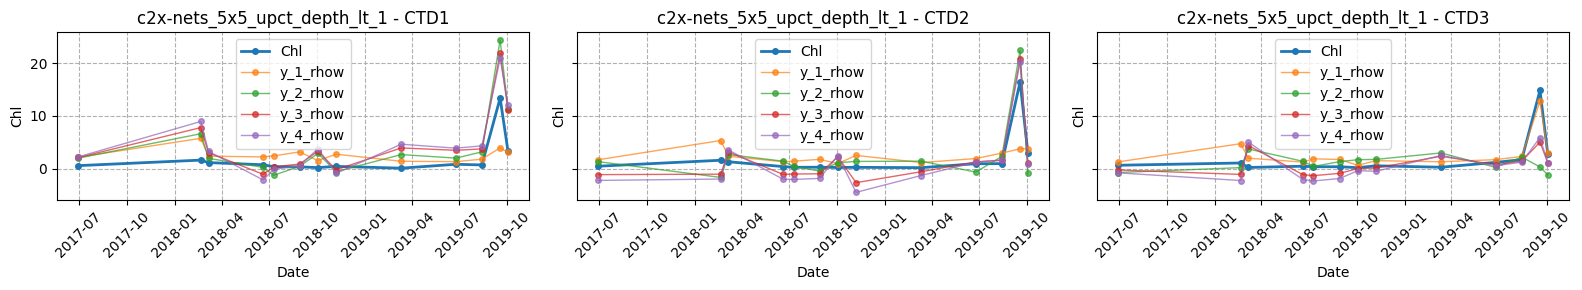

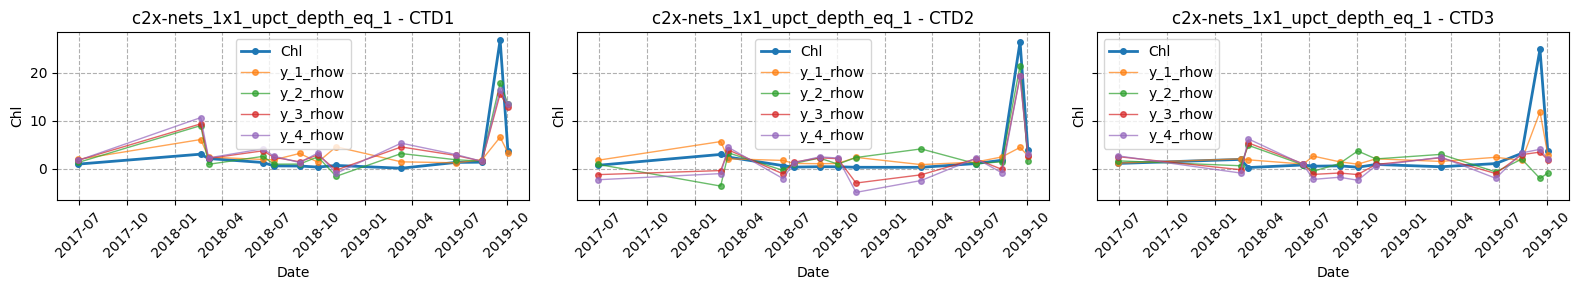

In [313]:
nombres_a_graficar = filtered_df[filtered_df.gt(0.7).any(axis=1)].index
for nombre_df in nombres_a_graficar:
    if nombre_df in dfs:
        df = dfs[nombre_df]
        columnas_necesarias = ["Chl", "rhow_B2", "rhow_B3", "rhow_B4", "rhow_B5", "rhow_B6"]
        if all(col in df.columns for col in columnas_necesarias):
            plot_time_series(df, nombre_df)

In [282]:
    #for i, dataset in enumerate(df.index):
nombres_a_graficar = ['c2x-nets_1x1_upct_depth_lt_2', 'c2x-nets_9x9_upct_depth_lt_2',
    'c2x-nets_3x3_upct_depth_eq_1', 'c2x-nets_9x9_upct_depth_eq_1',
    'c2x-nets_5x5_upct_depth_lt_2', 'c2x-nets_5x5_upct_depth_eq_1',
    'c2x-nets_3x3_upct_depth_lt_2', 'c2x-nets_3x3_upct_depth_lt_1',
    'c2x-nets_5x5_upct_depth_lt_1', 'c2x-nets_1x1_upct_depth_eq_1']



IndentationError: expected an indented block (3377303989.py, line 9)